# Clamped vs Unclamped Mask Loss Analysis

This notebook analyzes the difference between losses computed with different gate clamping strategies:

**Training behavior** (from optimizer):
- `masks` = `gate.forward()` (current: clamp max=1 only)  
- `sparsity_masks` = `gate.forward_unclamped()` (unclamped)

**Comparison modes**:
- **Current**: `torch.clamp(gate_output, max=1)` - upper bound only, negatives allowed
- **Strict**: `torch.clamp(gate_output, min=0, max=1)` - bounded to [0,1] 
- **Unclamped**: No clamping, allows any values

Currently implemented for TMS models with templates for ResidMLP extension.

In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch

warnings.filterwarnings('ignore')

# Add the project root to path so we can import spd modules
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from spd.configs import Config
from spd.data_utils import DatasetGeneratedDataLoader, SparseFeatureDataset
from spd.losses import calc_lp_sparsity_loss, calc_masked_recon_loss, calc_param_match_loss
from spd.models.component_model import ComponentModel
from spd.models.component_utils import calc_component_acts, calc_masks, calc_random_masks
from spd.utils import get_device

device = get_device()
print(f"Using device: {device}")

Using device: cuda


In [2]:
torch.set_grad_enabled(False)

## Loss Computation Functions

In [4]:
from spd.losses import calc_layerwise_recon_loss


def compute_losses_with_clamping_mode(
    model: ComponentModel,
    batch: torch.Tensor,
    config: Config,
    strict_clamp: bool = False
) -> dict[str, float]:
    """
    Compute losses using the exact optimizer logic with different clamping modes.
    
    Args:
        model: The ComponentModel with trained gates and components
        batch: Input batch data  
        config: SPD configuration
        strict_clamp: Whether to use strict clamping (True) or not (False)
m
    Returns:
        Dictionary of loss values
    """
    # Get components and gates (exact same as optimizer)
    gates = {k.removeprefix("gates.").replace("-", "."): v 
             for k, v in model.gates.items()}
    components = {k.removeprefix("components.").replace("-", "."): v 
                  for k, v in model.components.items()}
    
    # Forward pass (exact same as optimizer)
    target_out, pre_weight_acts = model.forward_with_pre_forward_cache_hooks(
        batch, module_names=list(components.keys())
    )
    
    As = {module_name: components[module_name].A for module_name in components}
    target_component_acts = calc_component_acts(pre_weight_acts=pre_weight_acts, As=As)
    
    masks, sparsity_masks = calc_masks(
        gates=gates, target_component_acts=target_component_acts, detach_inputs=False
    )
    
    if strict_clamp:
        masks = {k: v.clamp(0, 1) for k, v in masks.items()}
        sparsity_masks = {k: v.clamp(0, 1) for k, v in sparsity_masks.items()}
    # Compute losses (exact same as optimizer)
    losses = {}
    
    # Parameter matching loss
    n_params = sum(model.model.get_parameter(name + ".weight").numel() 
                   for name in components)
    
    losses['param_match'] = calc_param_match_loss(
        components=components,
        target_model=model.model,
        n_params=n_params,
        device=device,
    ).item()
    
    losses['masked_recon'] = calc_masked_recon_loss(
        model=model,
        batch=batch,
        components=components,
        masks=masks,
        target_out=target_out,
        loss_type=config.output_loss_type,
    ).item()
    
    torch.manual_seed(42)
    random_masks = calc_random_masks(masks=masks, n_random_masks=1)[0]
    
    #print(np.mean([v.mean().item() for v in random_masks.values()]))
    losses['random_masked_recon'] = calc_masked_recon_loss(
        model=model,
        batch=batch,
        components=components,
        masks=random_masks,
        target_out=target_out,
        loss_type=config.output_loss_type,
    ).item()
    
    losses['layerwise_reconstruction'] = calc_layerwise_recon_loss(
            model=model,
            batch=batch,
            device=device,
            components=components,
            masks=[masks],
            target_out=target_out,
            loss_type=config.output_loss_type,
        ).item()
    
    torch.manual_seed(42)
    layerwise_random_masks = calc_random_masks(
        masks=masks, n_random_masks=1
    )
    losses["layerwise_random_reconstruction"] = calc_layerwise_recon_loss(
                model=model,
                batch=batch,
                device=device,
                components=components,
                masks=layerwise_random_masks,
                target_out=target_out,
                loss_type=config.output_loss_type,
            ).item()
    
    # Sparsity loss  
    losses['lp_sparsity'] = calc_lp_sparsity_loss(
        sparsity_masks=sparsity_masks, 
        pnorm=config.pnorm
    ).item()
    
    return losses


## Load Model and Run Analysis

**Instructions:**
1. Update the `checkpoint_dir` path below to point to your trained model directory
2. The directory should contain: `tms.pth`, `tms_train_config.yaml`, `final_config.yaml`, and `model_*.pth` files
3. Run the cells below to perform the analysis

In [6]:
from spd.models.component_model import ComponentModel

MODEL_PATH = "/nlp/scr/nathu/apd/tms/out/randrecon1.00e+00_p1.00e+00_lpsp1.00e-04_m200_sd0_lr1.00e-03_bs4096_gtgate_mlp_ft40_hid10hid-layers1_20250620_144844_311/model_40000.pth"
# Load the decomposition model
model, config, _ = ComponentModel.from_pretrained(MODEL_PATH)
model.to(device)

ComponentModel(
  (model): TMSModel(
    (linear1): Linear(in_features=40, out_features=10, bias=False)
    (linear2): Linear(in_features=10, out_features=40, bias=True)
    (hidden_layers): ModuleList(
      (0): Linear(in_features=10, out_features=10, bias=False)
    )
  )
  (components): ModuleDict(
    (linear1): LinearComponent()
    (linear2): LinearComponent()
  )
  (gates): ModuleDict(
    (linear1): GateMLP()
    (linear2): GateMLP()
  )
)

In [7]:
task_config = config.task_config
dataset = SparseFeatureDataset(
        n_features=model.model.config.n_features,
        feature_probability=task_config.feature_probability,
        device=device,
        data_generation_type=task_config.data_generation_type,
        value_range=(0.0, 1.0),
        synced_inputs=None,
    )

loader = DatasetGeneratedDataLoader(dataset, batch_size=config.batch_size, shuffle=False)

In [12]:
from collections import defaultdict

from tqdm import tqdm

n_batches = 10000
no_clamp_results = defaultdict(list)
clamped_results = defaultdict(list)
data_iter = iter(loader)
for _ in tqdm(range(n_batches)):
    batch = next(data_iter)
    no_clamp = compute_losses_with_clamping_mode(model, batch[0], config, strict_clamp=False)
    clamped = compute_losses_with_clamping_mode(model, batch[0], config, strict_clamp=True)
    
    for k in no_clamp:
        no_clamp_results[k].append(no_clamp[k])
        clamped_results[k].append(clamped[k])


100%|██████████| 10000/10000 [01:10<00:00, 142.64it/s]


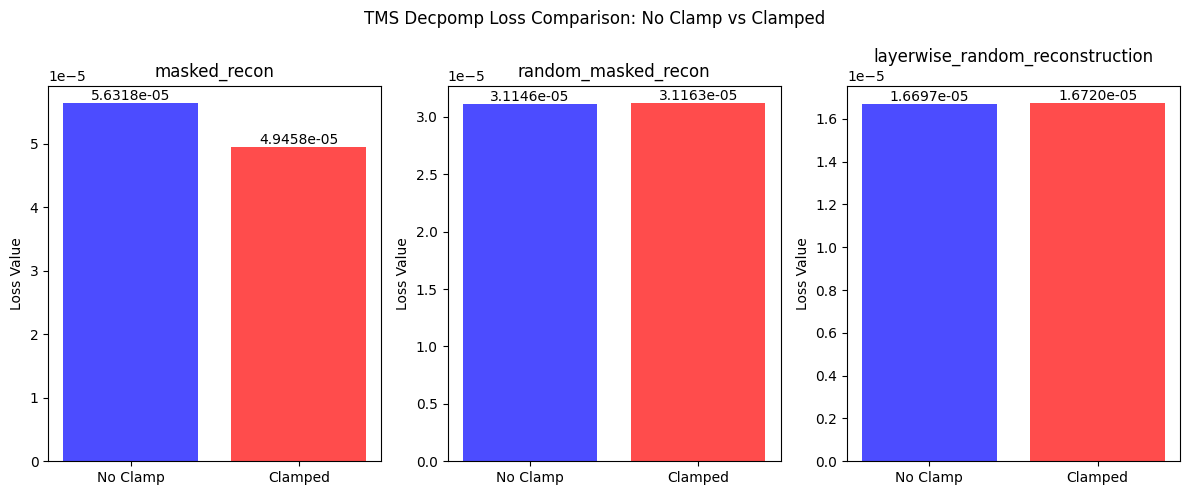

In [13]:

# Get keys
keys = ['masked_recon', 'random_masked_recon', 'layerwise_random_reconstruction']

# Create subplots
fig, axes = plt.subplots(1, len(keys), figsize=(4*len(keys), 5))
if len(keys) == 1:
    axes = [axes]  # Make it iterable if only one key

# Plot each key
for i, key in enumerate(keys):
    ax = axes[i]
    
    # Calculate means
    no_clamp_mean = np.mean(no_clamp_results[key])
    clamped_mean = np.mean(clamped_results[key])
    
    # Plot bars
    ax.bar(['No Clamp', 'Clamped'], [no_clamp_mean, clamped_mean], 
           color=['blue', 'red'], alpha=0.7)
    
    # Add value labels
    ax.text(0, no_clamp_mean, f'{no_clamp_mean:.4e}', 
            ha='center', va='bottom')
    ax.text(1, clamped_mean, f'{clamped_mean:.4e}', 
            ha='center', va='bottom')
    
    ax.set_title(key)
    ax.set_ylabel('Loss Value')

plt.suptitle('TMS Decpomp Loss Comparison: No Clamp vs Clamped')
plt.tight_layout()
plt.show()

In [56]:
np.mean(no_clamp_results['random_masked_recon']), np.mean(clamped_results['random_masked_recon'])

(np.float64(3.073796173339361e-05), np.float64(3.0503497564495775e-05))